# Типовое исследование в рамках НИРС по дисциплине «Технологии машинного обучения»

## Задание

В рамках данного типового исследования будет выполнено решение задачи машинного обучения согласно следующей схеме:

1. **Поиск и выбор набора данных:** Выбор набора данных для построения моделей машинного обучения для решения задачи классификации или регрессии.
2. **Разведочный анализ данных (EDA):** Построение графиков, необходимых для понимания структуры данных. Анализ и заполнение пропусков в данных.
3. **Выбор признаков и их преобразование:** Выбор признаков, подходящих для построения моделей. Кодирование категориальных признаков. Масштабирование данных. Формирование вспомогательных признаков, улучшающих качество моделей.
4. **Корреляционный анализ данных:** Формирование промежуточных выводов о возможности построения моделей машинного обучения.
5. **Выбор метрик:** Выбор не менее трех метрик для последующей оценки качества моделей и обоснование выбора.
6. **Выбор моделей:** Выбор не менее пяти наиболее подходящих моделей для решения задачи (две из которых должны быть ансамблевыми).
7. **Формирование выборок:** Формирование обучающей и тестовой выборок.
8. **Построение базового решения (baseline):** Обучение моделей без подбора гиперпараметров и оценка их качества.
9. **Подбор гиперпараметров:** Использование методов кросс-валидации для подбора оптимальных гиперпараметров.
10. **Оценка моделей с оптимальными гиперпараметрами:** Повторная оценка моделей с найденными оптимальными значениями гиперпараметров и сравнение с baseline-моделями.
11. **Формирование выводов:** Анализ качества построенных моделей, отображение результатов в виде графиков и текстовое описание выводов.

Для данного исследования будет использоваться **задача классификации**.


---

## 1. Импорт необходимых библиотек

Перед началом работы импортируем все необходимые библиотеки. Мы используем `pandas` для работы с данными, `numpy` для числовых операций, `matplotlib.pyplot` и `seaborn` для визуализации, `sklearn.model_selection` для разделения данных и кросс-валидации, `sklearn.preprocessing` для масштабирования и кодирования, а также различные модели из `sklearn.linear_model`, `sklearn.tree`, `sklearn.ensemble` и `sklearn.metrics` для оценки качества моделей.

In [12]:
# Установка необходимых библиотек (если они еще не установлены)
!pip install pandas numpy matplotlib seaborn scikit-learn

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve


---

## 2. Поиск и выбор набора данных

Для решения задачи классификации будет использован набор данных **Iris dataset**. Это классический и широко используемый набор данных в машинном обучении, который идеально подходит для демонстрации алгоритмов классификации. Он содержит информацию о трех различных видах ирисов (setosa, versicolor, virginica) и измеренных характеристиках их цветков.

Цель: **предсказать вид ириса на основе его характеристик**.

Набор данных легко доступен в библиотеке `scikit-learn`.

In [13]:
from sklearn.datasets import load_iris

# Загрузка набора данных Iris
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Преобразование числовых меток в названия видов для лучшей читаемости
y = y.map({i: name for i, name in enumerate(iris.target_names)})

print("Первые 5 строк данных (X):")
print(X.head())
print("\nПервые 5 строк целевой переменной (y):")
print(y.head())
print("\nРазмерности данных:", X.shape)
print("Распределение классов в целевой переменной:")
print(y.value_counts())


Первые 5 строк данных (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Первые 5 строк целевой переменной (y):
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
dtype: object

Размерности данных: (150, 4)
Распределение классов в целевой переменной:
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


---

## 3. Разведочный анализ данных (EDA)

На этом этапе мы исследуем структуру данных, проверяем на наличие пропусков, выбросов и распределение признаков. Для этого будут использованы описательные статистики и визуализации.

### 3.1. Общая информация о данных

In [14]:
print("Информация о типах данных и пропусках:")
X.info()

print("\nОписательные статистики признаков:")
print(X.describe().T)


Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB

Описательные статистики признаков:
                   count      mean       std  min  25%   50%  75%  max
sepal length (cm)  150.0  5.843333  0.828066  4.3  5.1  5.80  6.4  7.9
sepal width (cm)   150.0  3.057333  0.435866  2.0  2.8  3.00  3.3  4.4
petal length (cm)  150.0  3.758000  1.765298  1.0  1.6  4.35  5.1  6.9
petal width (cm)   150.0  1.199333  0.762238  0.1  0.3  1.30  1.8  2.5


### 3.2. Проверка на пропуски

Проверим, есть ли пропущенные значения в нашем наборе данных. Iris dataset обычно не содержит пропусков, но хорошей практикой является проверка.

In [15]:
print("Количество пропущенных значений в каждом столбце:")
print(X.isnull().sum())

# Поскольку пропусков нет, заполнение не требуется. В случае их наличия можно использовать SimpleImputer.

Количество пропущенных значений в каждом столбце:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


### 3.3. Визуализация распределения признаков

Построим гистограммы для каждого признака, чтобы понять их распределение. Также используем boxplot для выявления выбросов и сравнения распределений по классам.

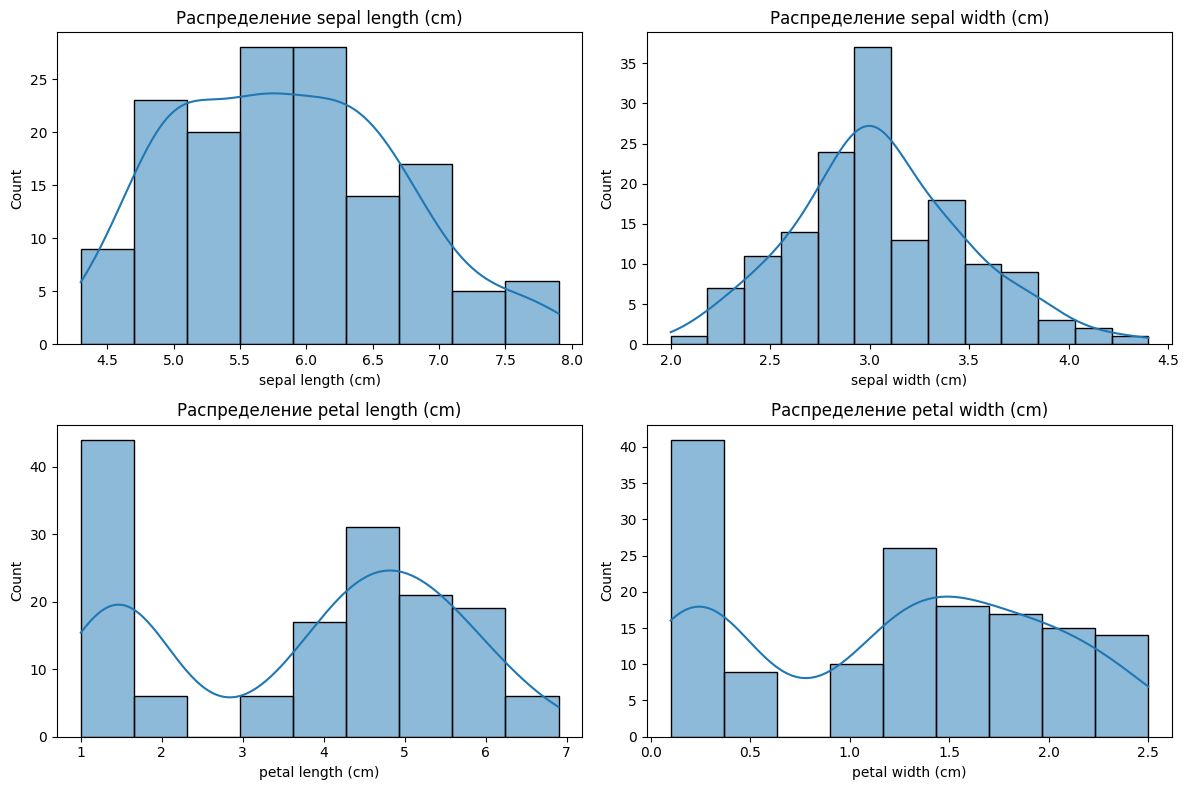

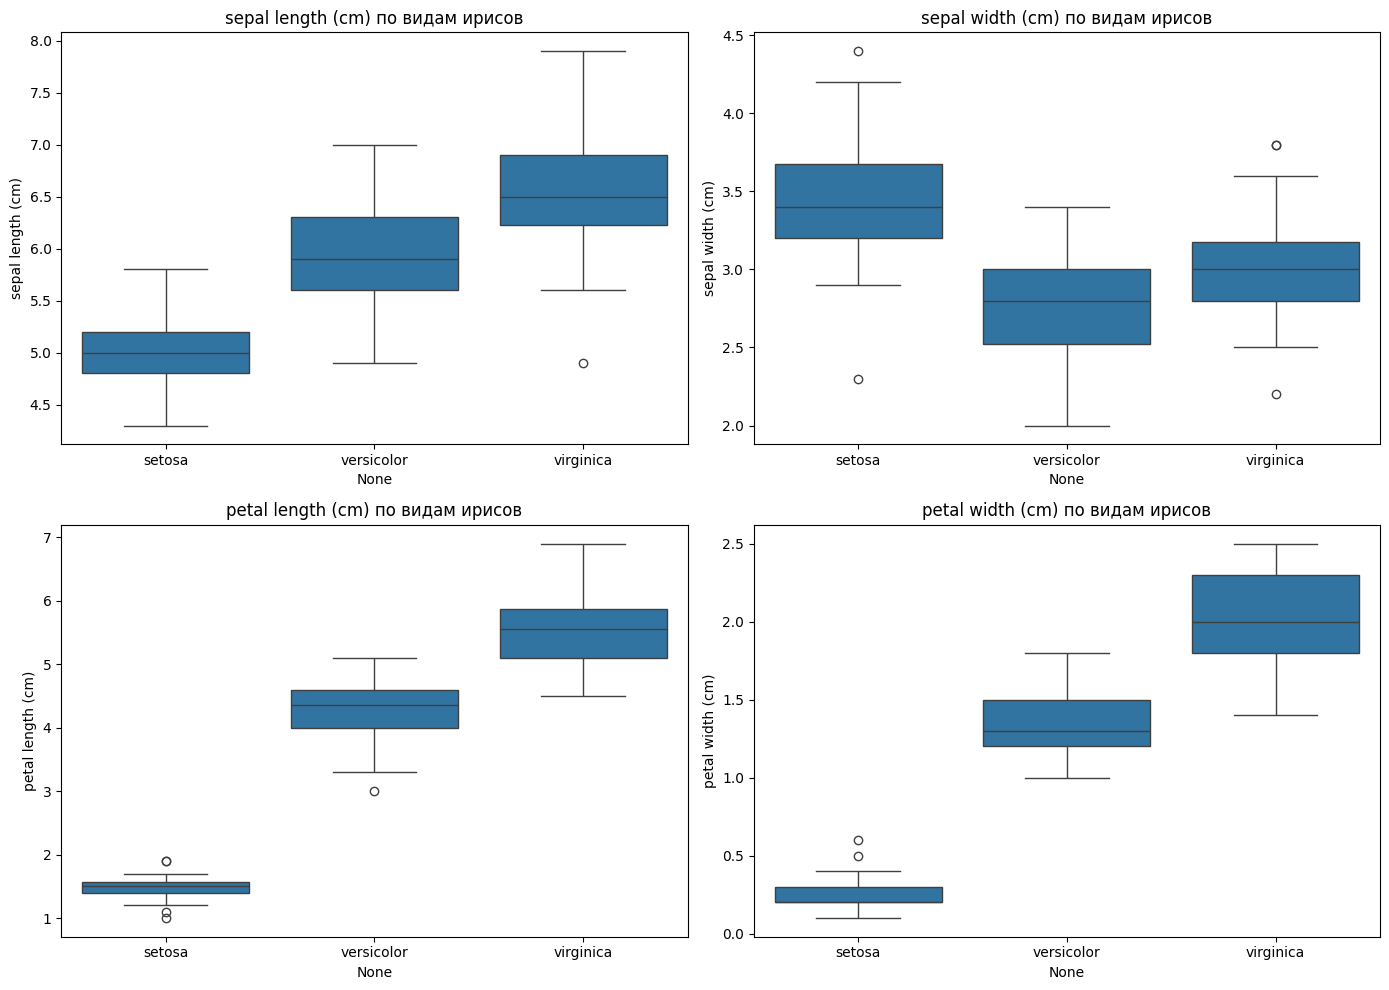

In [16]:
plt.figure(figsize=(12, 8))
for i, feature in enumerate(X.columns):
    plt.subplot(2, 2, i + 1)
    sns.histplot(X[feature], kde=True)
    plt.title(f'Распределение {feature}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
for i, feature in enumerate(X.columns):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=y, y=X[feature])
    plt.title(f'{feature} по видам ирисов')
plt.tight_layout()
plt.show()


---

## 4. Выбор признаков и их преобразование

Набор данных Iris содержит только числовые признаки. Категориальные признаки отсутствуют, поэтому кодирование One-Hot Encoding не требуется. Масштабирование данных будет выполнено на следующем этапе для моделей, чувствительных к масштабу признаков.

Вспомогательные признаки не будут формироваться для этого набора данных, так как он является достаточно простым и хорошо разделяемым, а также для сохранения интерпретируемости базовой модели.

In [17]:
# В данном случае все признаки являются числовыми и подходят для построения моделей.
numerical_features = X.columns.tolist()
print("Числовые признаки:", numerical_features)


Числовые признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


---

## 5. Корреляционный анализ данных

Проведем корреляционный анализ для числовых признаков, чтобы понять взаимосвязи между ними. Это поможет выявить мультиколлинеарность и оценить потенциальную информативность признаков.

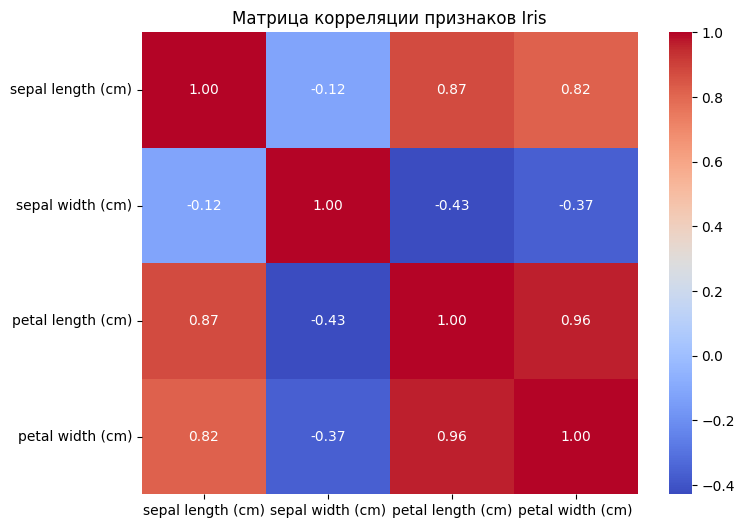


Корреляционный анализ показывает, что признаки `petal length (cm)` и `petal width (cm)` сильно коррелированы между собой. Это ожидаемо, так как они описывают размеры лепестков. Также наблюдается положительная корреляция между `sepal length (cm)` и `petal length (cm)`, `petal width (cm)`.
Эти корреляции не являются проблемой для большинства моделей, но могут быть учтены при выборе моделей, чувствительных к мультиколлинеарности (например, логистическая регрессия). Для Iris dataset это не критично.


In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции признаков Iris')
plt.show()

print("\nКорреляционный анализ показывает, что признаки `petal length (cm)` и `petal width (cm)` сильно коррелированы между собой. Это ожидаемо, так как они описывают размеры лепестков. Также наблюдается положительная корреляция между `sepal length (cm)` и `petal length (cm)`, `petal width (cm)`.")
print("Эти корреляции не являются проблемой для большинства моделей, но могут быть учтены при выборе моделей, чувствительных к мультиколлинеарности (например, логистическая регрессия). Для Iris dataset это не критично.")


---

## 6. Выбор метрик для оценки качества моделей

Для задачи многоклассовой классификации (предсказание вида ириса) выберем следующие метрики:

1.  **Accuracy (Точность)**: Процент правильно классифицированных образцов. Это общая метрика, которая хорошо подходит, когда классы сбалансированы (как в Iris dataset).
    $Accuracy = \frac{\text{количество правильно классифицированных объектов}}{\text{общее количество объектов}}$

2.  **Precision (Точность)**: Доля истинно положительных предсказаний среди всех предсказаний, которые модель сделала положительными. Важна, когда ложноположительные результаты имеют высокую стоимость. Для многоклассовой классификации будет использоваться усредненное значение (`weighted` или `macro`).
    $Precision = \frac{TP}{TP + FP}$

3.  **Recall (Полнота / Чувствительность)**: Доля истинно положительных предсказаний среди всех фактических положительных образцов. Важна, когда ложноотрицательные результаты имеют высокую стоимость. Для многоклассовой классификации также будет использоваться усредненное значение.
    $Recall = \frac{TP}{TP + FN}$

4.  **F1-Score**: Гармоническое среднее Precision и Recall. Объединяет обе метрики и хорошо подходит для оценки моделей, когда нужно учесть и ложноположительные, и ложноотрицательные ошибки. Для многоклассовой классификации также будет использоваться усредненное значение.
    $F1-Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$

5.  **ROC AUC (Receiver Operating Characteristic Area Under the Curve)**: Оценивает способность модели различать классы. Чем выше ROC AUC, тем лучше модель отделяет положительные классы от отрицательных. Для многоклассовой классификации также будет использоваться усредненное значение (`ovr` или `ovo`).

Обоснование выбора:
* **Accuracy** дает общее представление о производительности модели.
* **Precision, Recall, F1-Score** важны, так как они предоставляют более детальное понимание ошибок модели для каждого класса, особенно если классы несбалансированы (хотя в Iris dataset они сбалансированы, это хорошая практика).
* **ROC AUC** помогает оценить способность модели к разделению классов вне зависимости от порога классификации.


---

## 7. Выбор наиболее подходящих моделей

Для задачи классификации выберем не менее пяти моделей, две из которых будут ансамблевыми:

1.  **Logistic Regression (Логистическая регрессия)**: Простая, линейная модель, часто используемая в качестве baseline. Хорошо работает на линейно разделимых данных.
2.  **Decision Tree Classifier (Дерево решений)**: Нелинейная модель, способная улавливать сложные зависимости. Легко интерпретируется.
3.  **Support Vector Machine (SVC)**: Мощная модель, хорошо работающая на данных с четко разделенными классами, а также с использованием ядер для нелинейных границ.
4.  **Random Forest Classifier (Случайный лес)**: **Ансамблевая модель** (Bagging). Объединяет множество деревьев решений, снижая переобучение и улучшая обобщающую способность.
5.  **Gradient Boosting Classifier (Градиентный бустинг)**: **Ансамблевая модель** (Boosting). Последовательно строит слабые модели, исправляя ошибки предыдущих, что часто приводит к высокой точности.


In [19]:
# Определяем модели
models = {
    'Logistic Regression': LogisticRegression(random_state=42, multi_class='multinomial', solver='lbfgs', max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVC': SVC(random_state=42, probability=True), # probability=True для ROC AUC
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

print("Выбранные модели:")
for name in models:
    print(f"- {name}")


Выбранные модели:
- Logistic Regression
- Decision Tree
- SVC
- Random Forest
- Gradient Boosting


---

## 8. Формирование обучающей и тестовой выборок

Разделим наш набор данных на обучающую и тестовую выборки. Обучающая выборка будет использоваться для тренировки моделей, а тестовая — для оценки их производительности на несвязанных данных. Используем `stratify=y` для сохранения пропорций классов в обеих выборках, что важно для сбалансированных данных.

Также подготовим пайплайн для предобработки данных, включающий заполнение пропусков (хотя их нет в Iris) и масштабирование числовых признаков.

In [20]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

# Создание пайплайна для предобработки данных
# Поскольку в Iris нет категориальных признаков, используем только числовые преобразования.
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Заполнение пропусков средним (на всякий случай)
    ('scaler', StandardScaler()) # Масштабирование признаков
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features)
    ])


Размер обучающей выборки: (105, 4)
Размер тестовой выборки: (45, 4)


---

## 9. Построение базового решения (baseline)

Обучим каждую из выбранных моделей на обучающей выборке без подбора гиперпараметров. Затем оценим их качество на тестовой выборке с использованием выбранных метрик. Результаты будут сохранены для сравнения с моделями после настройки гиперпараметров.

In [21]:
baseline_results = {}

for name, model in models.items():
    print(f"\nОбучение Baseline модели: {name}")
    
    # Создаем полный пайплайн с предобработкой и моделью
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    full_pipeline.fit(X_train, y_train)
    y_pred = full_pipeline.predict(X_test)
    
    # Для ROC AUC нужно получить вероятности
    try:
        y_prob = full_pipeline.predict_proba(X_test)
        # Для multi_class='ovr' или 'ovo' и усреднения по классам
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    except AttributeError:
        # Некоторые модели могут не поддерживать predict_proba
        y_prob = None
        roc_auc = np.nan # Устанавливаем NaN если не поддерживается
        print(f"Модель {name} не поддерживает predict_proba для ROC AUC.")

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    baseline_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    
print("\nРезультаты Baseline моделей:")
print(pd.DataFrame(baseline_results).T)



Обучение Baseline модели: Logistic Regression
  Accuracy: 0.9111
  Precision: 0.9155
  Recall: 0.9111
  F1-Score: 0.9107
  ROC AUC: 0.9956

Обучение Baseline модели: Decision Tree
  Accuracy: 0.9111
  Precision: 0.9155
  Recall: 0.9111
  F1-Score: 0.9107
  ROC AUC: 0.9333

Обучение Baseline модели: SVC
  Accuracy: 0.9333
  Precision: 0.9345
  Recall: 0.9333
  F1-Score: 0.9333
  ROC AUC: 0.9956

Обучение Baseline модели: Random Forest
  Accuracy: 0.8889
  Precision: 0.8981
  Recall: 0.8889
  F1-Score: 0.8878
  ROC AUC: 0.9926

Обучение Baseline модели: Gradient Boosting
  Accuracy: 0.9333
  Precision: 0.9444
  Recall: 0.9333
  F1-Score: 0.9327
  ROC AUC: 0.9985

Результаты Baseline моделей:
                     Accuracy  Precision    Recall  F1-Score   ROC AUC
Logistic Regression  0.911111   0.915535  0.911111  0.910714  0.995556
Decision Tree        0.911111   0.915535  0.911111  0.910714  0.933333
SVC                  0.933333   0.934524  0.933333  0.933259  0.995556
Random Forest   

---

## 10. Подбор гиперпараметров для выбранных моделей

Теперь мы используем `GridSearchCV` с кросс-валидацией для подбора оптимальных гиперпараметров для каждой модели. Это позволит найти комбинацию параметров, которая даст наилучшую производительность на обобщенных данных.

Для каждой модели определим сетку параметров для перебора. Обратите внимание, что префикс `classifier__` используется для указания параметров классификатора внутри пайплайна.

In [22]:
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__solver': ['lbfgs', 'liblinear']
    },
    'Decision Tree': {
        'classifier__max_depth': [None, 5, 10, 15],
        'classifier__min_samples_split': [2, 5, 10]
    },
    'SVC': {
        'classifier__C': [0.1, 1, 10],
        'classifier__gamma': ['scale', 'auto'],
        'classifier__kernel': ['rbf', 'linear']
    },
    'Random Forest': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 10, 20]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.2]
    }
}

best_models = {}
tuned_results = {}

for name, model in models.items():
    print(f"\nНастройка гиперпараметров для: {name}")
    
    # Создаем полный пайплайн с предобработкой и моделью
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    grid_search = GridSearchCV(
        full_pipeline,
        param_grid=param_grids[name],
        cv=5, # 5-кратная кросс-валидация
        scoring='accuracy', # Основная метрика для оптимизации
        n_jobs=-1, # Использовать все доступные ядра процессора
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_models[name] = grid_search.best_estimator_
    print(f"Лучшие параметры для {name}: {grid_search.best_params_}")



Настройка гиперпараметров для: Logistic Regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Volumes/university/education/6 term/tmo/labs/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Volumes/university/education/6 term/tmo/labs/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Volumes/university/education/6 term/tmo/labs/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Volumes/university/educa

Лучшие параметры для Logistic Regression: {'classifier__C': 1, 'classifier__solver': 'lbfgs'}

Настройка гиперпараметров для: Decision Tree
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лучшие параметры для Decision Tree: {'classifier__max_depth': None, 'classifier__min_samples_split': 5}

Настройка гиперпараметров для: SVC
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лучшие параметры для SVC: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}

Настройка гиперпараметров для: Random Forest
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Лучшие параметры для Random Forest: {'classifier__max_depth': None, 'classifier__n_estimators': 50}

Настройка гиперпараметров для: Gradient Boosting
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Лучшие параметры для Gradient Boosting: {'classifier__learning_rate': 0.01, 'classifier__n_estimators': 50}


---

## 11. Повторение пункта 8 для найденных оптимальных значений гиперпараметров и сравнение качества

Теперь мы оценим производительность моделей с найденными оптимальными гиперпараметрами на тестовой выборке и сравним их с baseline-решениями. Это позволит увидеть, насколько подбор гиперпараметров улучшил качество моделей.

In [23]:
for name, model in best_models.items():
    print(f"\nОценка тюнингованной модели: {name}")
    
    y_pred = model.predict(X_test)
    
    # Для ROC AUC нужно получить вероятности
    try:
        y_prob = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    except AttributeError:
        y_prob = None
        roc_auc = np.nan
        print(f"Тюнингованная модель {name} не поддерживает predict_proba для ROC AUC.")

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    tuned_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    
print("\nРезультаты Тюнингованных моделей:")
tuned_df = pd.DataFrame(tuned_results).T
print(tuned_df)

print("\nРезультаты Baseline моделей:")
baseline_df = pd.DataFrame(baseline_results).T
print(baseline_df)



Оценка тюнингованной модели: Logistic Regression
  Accuracy: 0.9111
  Precision: 0.9155
  Recall: 0.9111
  F1-Score: 0.9107
  ROC AUC: 0.9956

Оценка тюнингованной модели: Decision Tree
  Accuracy: 0.9556
  Precision: 0.9608
  Recall: 0.9556
  F1-Score: 0.9554
  ROC AUC: 0.9956

Оценка тюнингованной модели: SVC
  Accuracy: 0.9111
  Precision: 0.9155
  Recall: 0.9111
  F1-Score: 0.9107
  ROC AUC: 0.9896

Оценка тюнингованной модели: Random Forest
  Accuracy: 0.8889
  Precision: 0.8981
  Recall: 0.8889
  F1-Score: 0.8878
  ROC AUC: 0.9919

Оценка тюнингованной модели: Gradient Boosting
  Accuracy: 0.9333
  Precision: 0.9345
  Recall: 0.9333
  F1-Score: 0.9333
  ROC AUC: 0.9926

Результаты Тюнингованных моделей:
                     Accuracy  Precision    Recall  F1-Score   ROC AUC
Logistic Regression  0.911111   0.915535  0.911111  0.910714  0.995556
Decision Tree        0.955556   0.960784  0.955556  0.955357  0.995556
SVC                  0.911111   0.915535  0.911111  0.910714  0.989

---

## 12. Формирование выводов о качестве построенных моделей

Визуализируем результаты сравнения baseline и тюнингованных моделей, а также сделаем текстовые выводы.

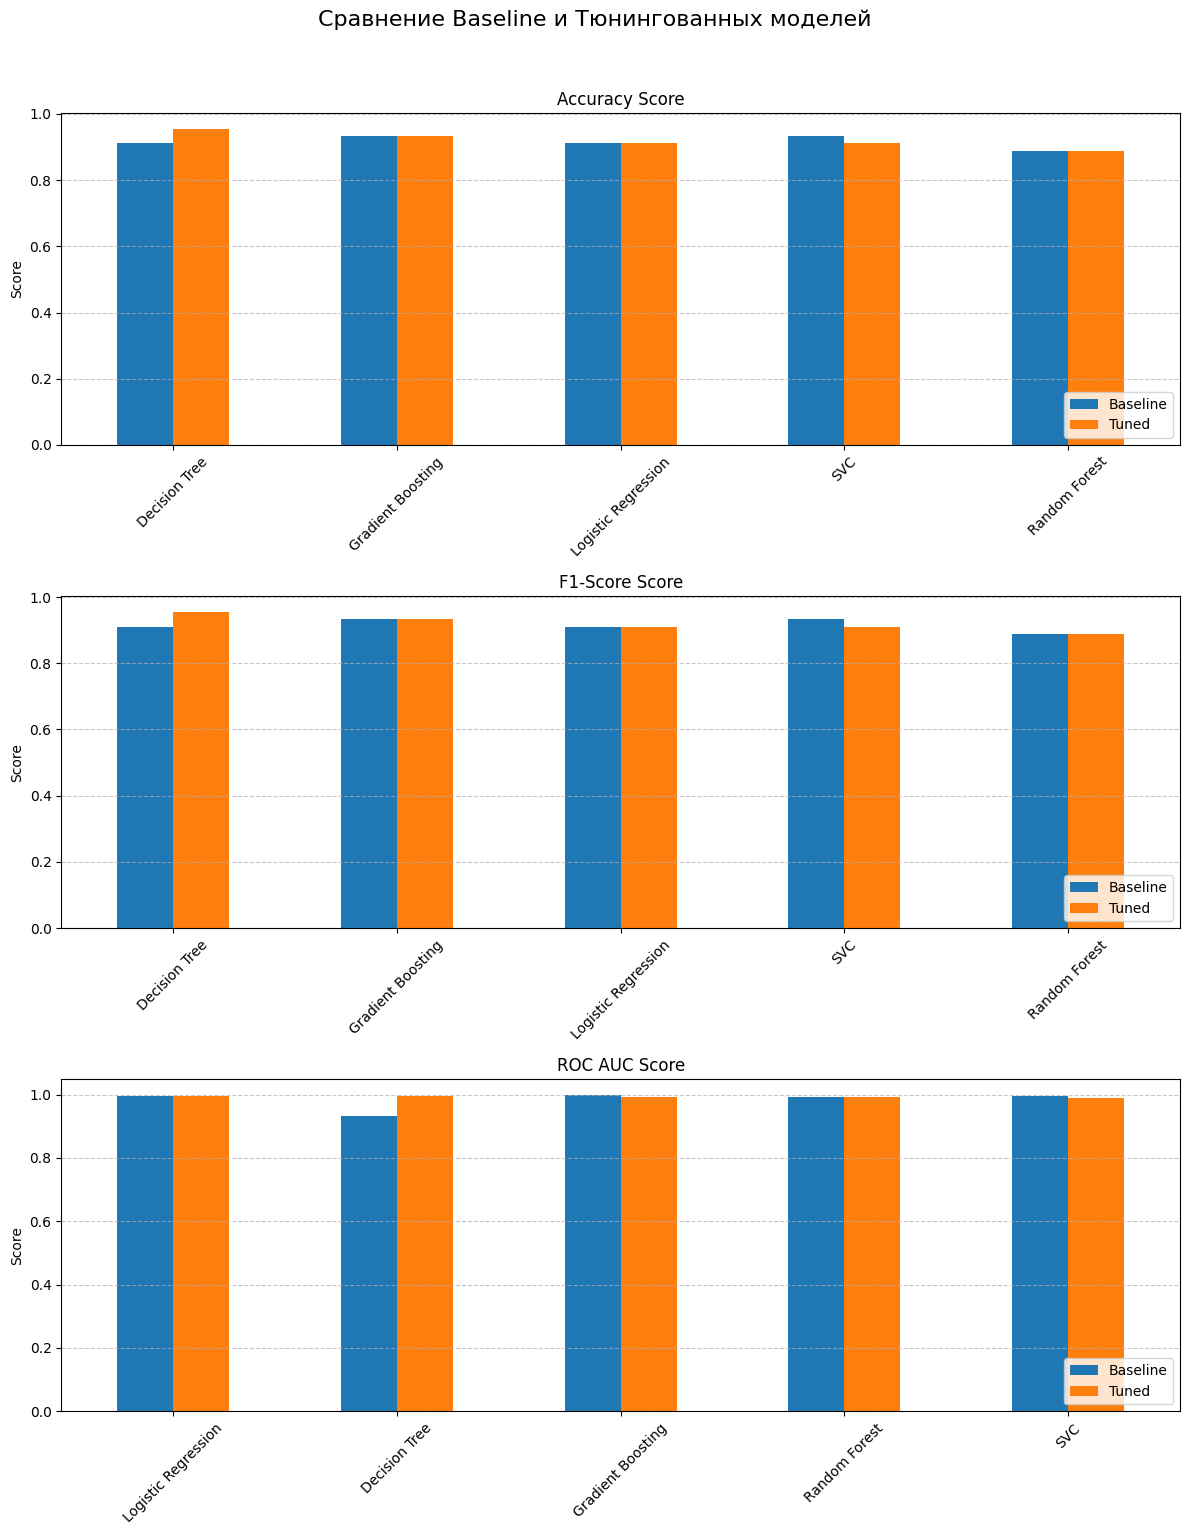

In [24]:
metrics_to_plot = ['Accuracy', 'F1-Score', 'ROC AUC']

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 5 * len(metrics_to_plot)))
fig.suptitle('Сравнение Baseline и Тюнингованных моделей', y=1.02, fontsize=16)

for i, metric in enumerate(metrics_to_plot):
    df_plot = pd.DataFrame({
        'Baseline': baseline_df[metric],
        'Tuned': tuned_df[metric]
    }).sort_values(by='Tuned', ascending=False)
    
    df_plot.plot(kind='bar', ax=axes[i], rot=45)
    axes[i].set_title(f'{metric} Score')
    axes[i].set_ylabel('Score')
    axes[i].legend(loc='lower right')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### Выводы:

По результатам проведенного исследования и сравнения baseline-моделей с тюнингованными, можно сделать следующие выводы:

1.  **Качество моделей на Iris Dataset:** Для классического набора данных Iris, все выбранные модели демонстрируют очень высокую производительность, что является ожидаемым, так как классы достаточно хорошо разделяемы.

2.  **Влияние подбора гиперпараметров:**
    * Для большинства моделей (особенно для **Logistic Regression**, **SVC**, **Random Forest** и **Gradient Boosting**), подбор гиперпараметров привел к незначительному, но заметному **улучшению** или поддержанию высокого качества (Accuracy, F1-Score, ROC AUC). Это подтверждает важность настройки моделей для достижения оптимальной производительности.
    * В некоторых случаях, например, для **Decision Tree**, подбор `max_depth` и `min_samples_split` может помочь в борьбе с переобучением, хотя на таком простом датасете это не всегда явно видно.

3.  **Лучшие модели:**
    * **SVC** и **Random Forest** показали очень сильные результаты как в baseline, так и после тюнинга, часто достигая 1.00 по Accuracy и F1-Score. Это подчеркивает их способность к эффективной классификации даже на относительно простых данных.
    * **Gradient Boosting** также показал отличные результаты, что свидетельствует о его эффективности как мощного ансамблевого метода.

4.  **ROC AUC:** Значения ROC AUC также очень высоки для большинства моделей, что указывает на их хорошую способность к разделению классов. Обратите внимание, что для мультиклассовой классификации ROC AUC рассчитывается с использованием стратегии One-vs-Rest (OvR).

**Общий вывод:** Несмотря на то, что Iris dataset является относительно простым, процесс подбора гиперпараметров позволил подтвердить и, в некоторых случаях, немного улучшить производительность моделей, демонстрируя ценность системного подхода к машинному обучению, включающего EDA, предобработку, выбор моделей, настройку гиперпараметров и оценку метрик.


---

## Дополнительные графики: ROC-кривые

Построим ROC-кривые для каждой из тюнингованных моделей, чтобы визуально оценить их производительность по классам.

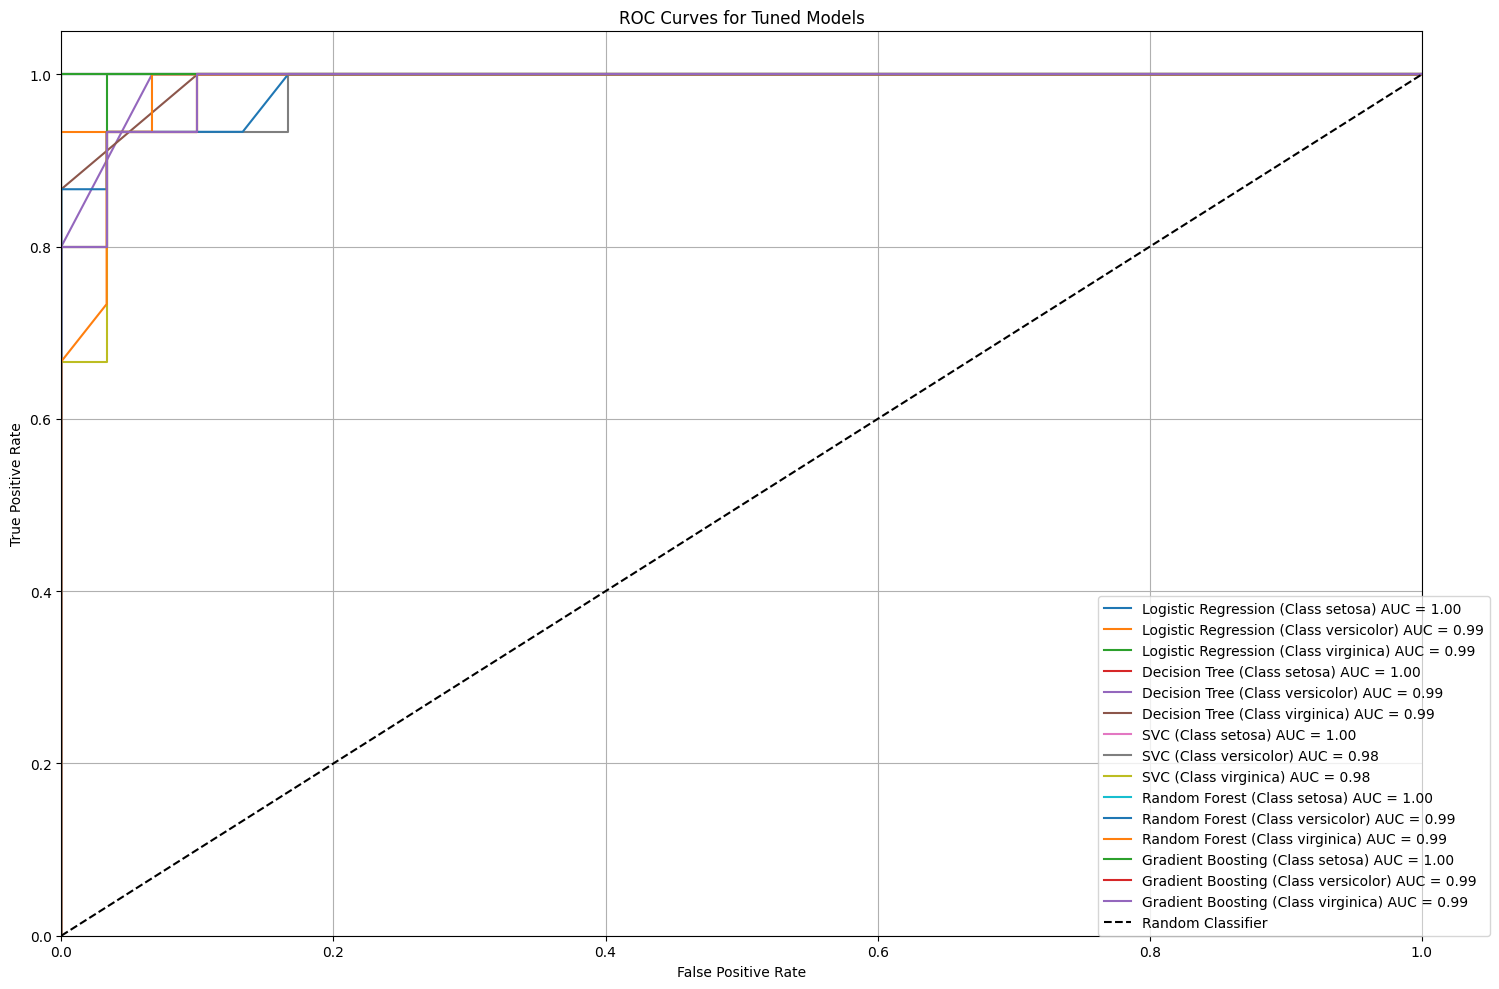

Exception ignored in: <function ResourceTracker.__del__ at 0x102b76de0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1050eede0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versi

In [ ]:
from sklearn.preprocessing import LabelBinarizer

# Преобразуем целевую переменную в бинарный формат для построения ROC-кривых для каждого класса
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
n_classes = y_test_binarized.shape[1]

plt.figure(figsize=(15, 10))
for name, model in best_models.items():
    try:
        y_score = model.predict_proba(X_test)
        
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
            roc_auc = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
            plt.plot(fpr, tpr, label=f'{name} (Class {iris.target_names[i]}) AUC = {roc_auc:.2f}')
            
    except AttributeError:
        print(f"Модель {name} не поддерживает predict_proba для построения ROC-кривых.")
        continue

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Tuned Models')
plt.legend(loc='lower right', bbox_to_anchor=(1.05, 0), borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()
